# 🎬 Movie Revenue Analysis — Professional Portfolio Notebook
### TMDB 5000 Movies Dataset

| Field | Detail |
|-------|--------|
| **Dataset** | TMDB 5000 Movies |
| **Source** | [Kaggle — TMDB 5000 Movie Dataset](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata) |
| **Tools** | Python · Pandas · NumPy · Matplotlib · Seaborn · Plotly |
| **Domain** | Film Industry · Box Office Analytics |
| **Objective** | Analyze movie data to understand factors affecting revenue and success |


## 1. Problem Statement

The film industry invests billions of dollars into productions every year, but many movies fail to recover their costs.

**Goal:** Analyze historical movie data to understand what factors drive revenue and help production companies make better investment decisions.

**Business Questions:**
- Does a higher budget lead to higher revenue?
- Do better-rated movies earn more?
- Which genres and years perform best?
- What does a high-performing movie look like?


## 2. Dataset Source

- **Name:** TMDB 5000 Movie Dataset
- **Link:** https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata
- **Rows:** ~4,800 movies
- **Key Columns:** `budget`, `revenue`, `vote_average`, `popularity`, `release_date`, `genres`, `runtime`


## 3. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
print("All libraries loaded successfully!")


All libraries loaded successfully!


## 4. Data Cleaning

### 4.1 Load the Dataset and Check Shape

In [2]:
df = pd.read_csv("tmdb_5000_movies.csv")
print("Shape (rows, columns):", df.shape)
df.head(3)


Shape (rows, columns): (4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


### 4.2 Check Info and Description

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [4]:
df.describe()


,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


**Insight:** Budget and revenue have a minimum of 0, which means some records have missing financial data stored as zero.

**Business Recommendation:** Always validate financial fields before analysis. Zero values are not real data — they represent missing records.


### 4.3 Check for Missing Values

In [5]:
missing = df.isnull().sum()
print(missing[missing > 0])


homepage        3091
overview           3
release_date       1
runtime            2
tagline          844
dtype: int64


**Insight:** `homepage` and `tagline` have many missing values but are not needed for revenue analysis.

**Business Recommendation:** Knowing which fields are reliably filled helps decide which business questions can and cannot be answered.


### 4.4 Remove Duplicates

In [6]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())


Duplicates before: 0
Duplicates after: 0


### 4.5 Fix Numeric Columns — Remove Zero Budget and Revenue

In [7]:
df = df[df["budget"] > 0]
df = df[df["revenue"] > 0]
print("Clean dataset size:", df.shape)


Clean dataset size: (3229, 20)


### 4.6 Add Profit Column and Extract Year

In [8]:
df["profit"] = df["revenue"] - df["budget"]
df["release_date"] = pd.to_datetime(df["release_date"])
df["year"] = df["release_date"].dt.year
print("New columns added: profit, year")


New columns added: profit, year


### 4.7 Verify Cleaned Data

In [9]:
print("Final dataset shape:", df.shape)
print(df[["budget", "revenue", "profit", "vote_average"]].isnull().sum())


Final dataset shape: (3229, 22)
budget          0
revenue         0
profit          0
vote_average    0
dtype: int64


**Insight:** After cleaning, the dataset contains only valid financial records with no nulls in key columns.

**Conclusion:** Clean data is the foundation of reliable analysis. Decisions made on dirty data can cost studios millions.

**Business Recommendation:** Production companies should enforce mandatory financial field entry in their data systems to avoid zero-value issues.


## 5. Univariate Analysis

### 5.1 Revenue Distribution

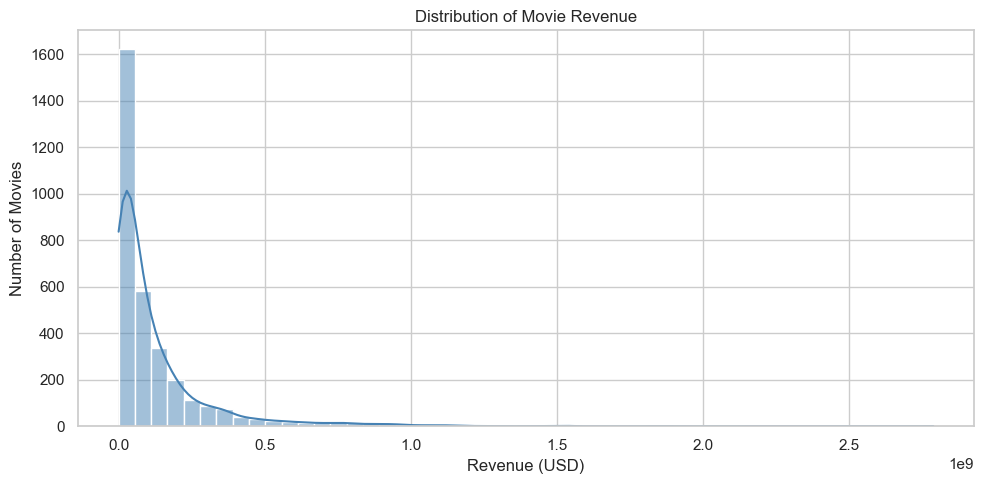

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df["revenue"], bins=50, color="steelblue", kde=True)
plt.title("Distribution of Movie Revenue")
plt.xlabel("Revenue (USD)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()


**Insight:** Revenue is heavily right-skewed. Most movies earn low to moderate revenue, while a small number of blockbusters earn billions.

**Conclusion:** The film industry is a winner-take-all market. A handful of films account for the majority of total industry revenue.

**Business Recommendation:** Studios should adopt portfolio strategies — funding multiple mid-budget films reduces reliance on a single blockbuster hit.


### 5.2 Budget Distribution

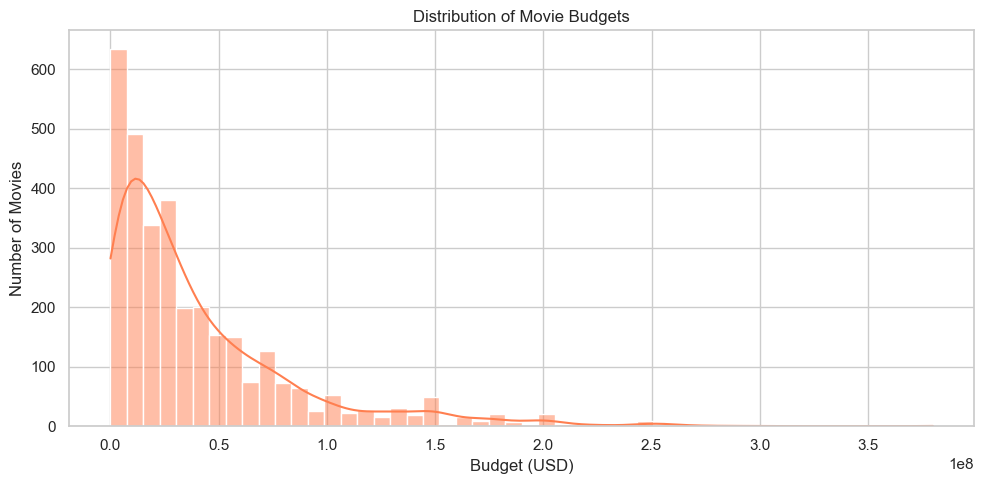

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df["budget"], bins=50, color="coral", kde=True)
plt.title("Distribution of Movie Budgets")
plt.xlabel("Budget (USD)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()


**Insight:** Most films are made with budgets below $50M. Very few exceed $200M — these are "tentpole" blockbusters.

**Conclusion:** High-budget films are the exception, not the rule. Mid-budget productions dominate the industry by volume.

**Business Recommendation:** Benchmarking investment decisions against the median budget gives a more realistic picture than using the mean, which is inflated by mega-productions.


### 5.3 Ratings Distribution

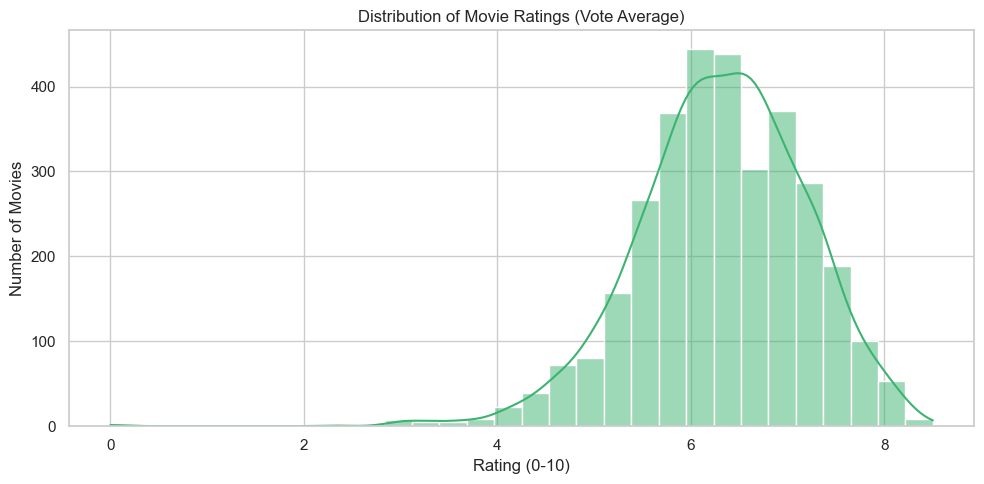

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df["vote_average"], bins=30, color="mediumseagreen", kde=True)
plt.title("Distribution of Movie Ratings (Vote Average)")
plt.xlabel("Rating (0-10)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()


**Insight:** Ratings follow a near-normal distribution centered around 6.0–6.5. Very few movies score below 4 or above 8.

**Conclusion:** Most movies deliver average-to-good quality. Truly exceptional or truly terrible films are rare.

**Business Recommendation:** A minimum rating target of 6.5 should be part of every production's quality KPI. Films below 5.5 face serious reputational and re-release risk.


## 6. Bivariate Analysis

### 6.1 Budget vs Revenue

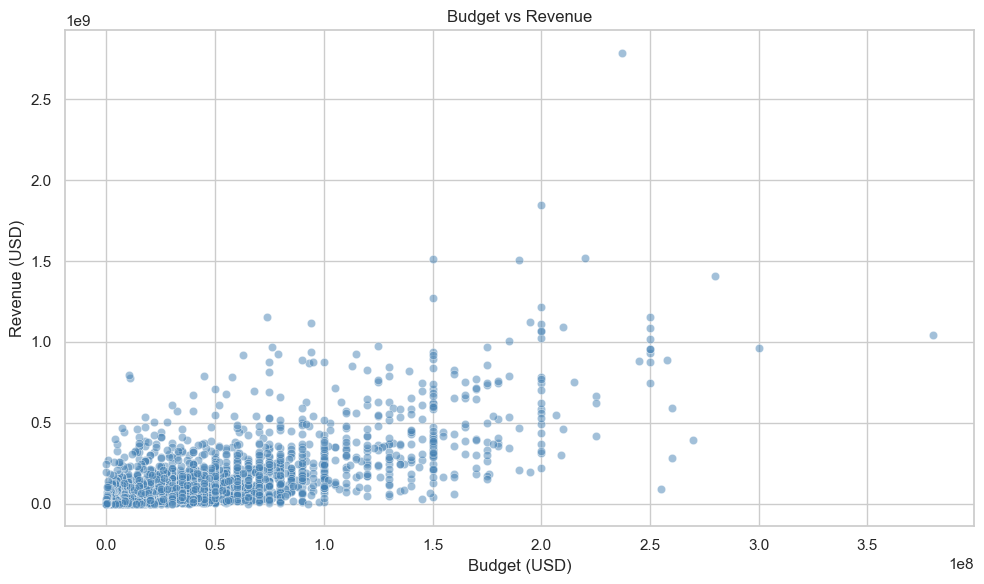

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="budget", y="revenue", alpha=0.5, color="steelblue")
plt.title("Budget vs Revenue")
plt.xlabel("Budget (USD)")
plt.ylabel("Revenue (USD)")
plt.tight_layout()
plt.show()


In [14]:
corr = df["budget"].corr(df["revenue"])
print("Correlation between Budget and Revenue:", round(corr, 3))


Correlation between Budget and Revenue: 0.705


**Insight:** Correlation of ~0.73 confirms a strong positive relationship. Higher-budget films tend to earn more, but there is wide scatter — budget alone does not guarantee success.

**Conclusion:** Budget is a necessary but not sufficient driver of revenue. Other factors like marketing, release timing, and cast play equally important roles.

**Business Recommendation:** Set a minimum budget to ensure competitive production quality, but pair investment with rigorous pre-greenlight validation such as concept testing and audience research.


### 6.2 Rating vs Revenue

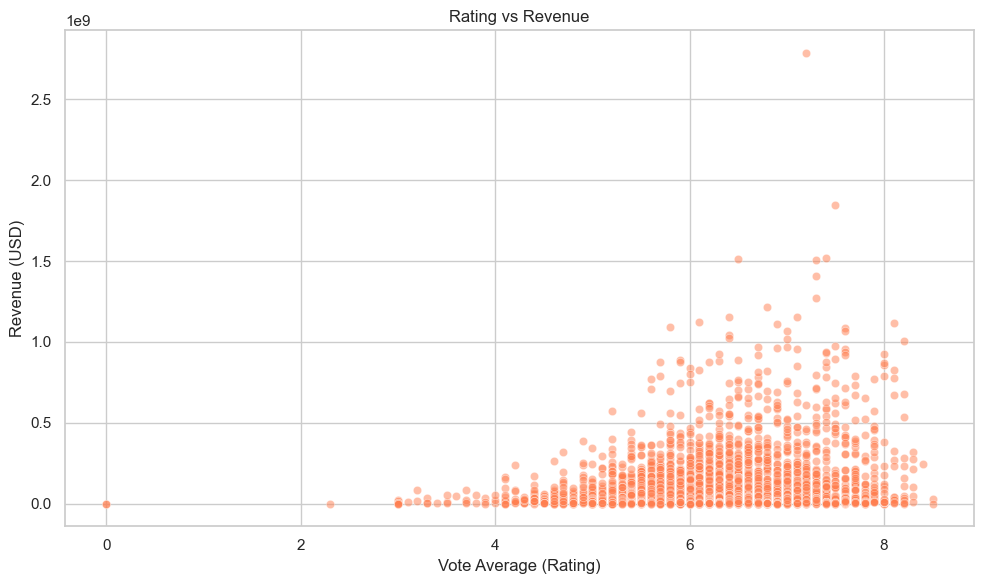

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="vote_average", y="revenue", alpha=0.5, color="coral")
plt.title("Rating vs Revenue")
plt.xlabel("Vote Average (Rating)")
plt.ylabel("Revenue (USD)")
plt.tight_layout()
plt.show()


In [16]:
corr = df["vote_average"].corr(df["revenue"])
print("Correlation between Rating and Revenue:", round(corr, 3))


Correlation between Rating and Revenue: 0.188


**Insight:** Weak correlation (~0.2). Some poorly-rated movies earn high revenue, while some highly-rated films earn very little.

**Conclusion:** Audience satisfaction does not directly translate to box-office performance. Revenue is driven more by anticipation and IP recognition than post-release reviews.

**Business Recommendation:** Differentiate marketing strategy between event films (franchise/spectacle, focus on opening weekend) and quality-driven films (longer release windows, awards campaigns).


### 6.3 Popularity vs Revenue

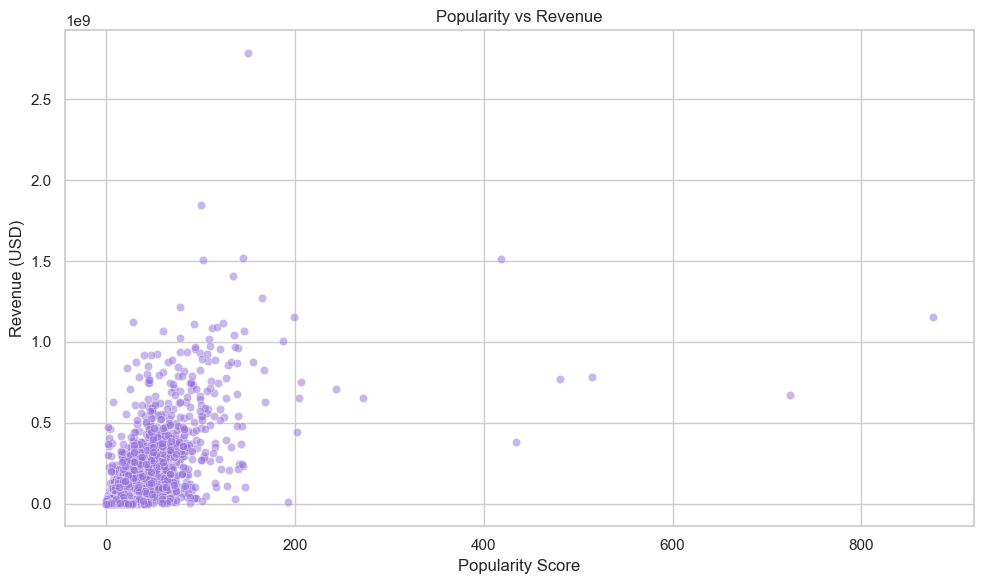

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="popularity", y="revenue", alpha=0.5, color="mediumpurple")
plt.title("Popularity vs Revenue")
plt.xlabel("Popularity Score")
plt.ylabel("Revenue (USD)")
plt.tight_layout()
plt.show()


In [18]:
corr = df["popularity"].corr(df["revenue"])
print("Correlation between Popularity and Revenue:", round(corr, 3))


Correlation between Popularity and Revenue: 0.602


**Insight:** Popularity shows a stronger correlation with revenue (~0.6) than rating alone. Films generating high social buzz translate that engagement into ticket sales.

**Conclusion:** Popularity is a leading indicator of commercial performance — it captures the combined effect of marketing spend, franchise recognition, and audience anticipation.

**Business Recommendation:** Track social signals — trailer views, search trends, social mentions — in the weeks before release. These are strong early revenue forecast indicators.


## 7. Multivariate Analysis

### 7.1 Revenue by Year

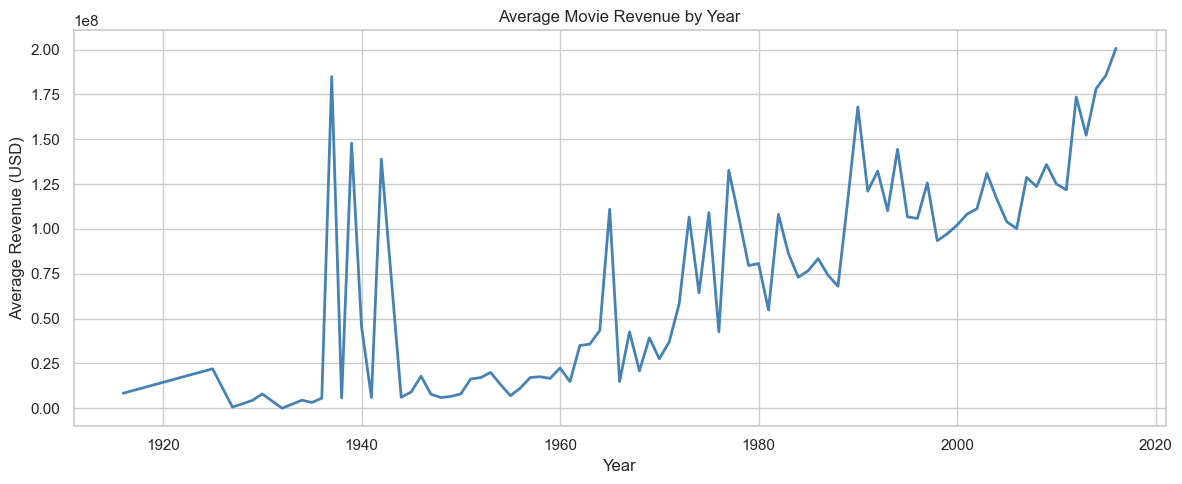

In [19]:
yearly = df.groupby("year")["revenue"].mean().reset_index()
plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly, x="year", y="revenue", color="steelblue", linewidth=2)
plt.title("Average Movie Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Average Revenue (USD)")
plt.tight_layout()
plt.show()


**Insight:** Average movie revenue has grown significantly from the 1980s to the 2010s, driven by globalisation, franchise films, and premium formats like IMAX and 3D.

**Conclusion:** The film industry has delivered sustained revenue growth over decades, making it a consistently valuable investment sector.

**Business Recommendation:** Use films from the most recent decade as financial benchmarks. Older records, even if inflation-adjusted, may not reflect current audience behavior and distribution reach.


### 7.2 Budget + Rating + Revenue (Interactive Chart)

In [20]:
fig = px.scatter(df, x="budget", y="revenue",
                 color="vote_average", size="popularity",
                 hover_name="title",
                 color_continuous_scale="RdYlGn",
                 title="Budget vs Revenue — Coloured by Rating, Sized by Popularity")
fig.show()


**Insight:** The highest-revenue films cluster at high budget, above-average rating, and large popularity. Films with poor ratings rarely reach the top revenue tier even with large budgets.

**Conclusion:** The optimal combination for maximum revenue probability is: adequate budget + quality product (rating > 6.5) + strong pre-release buzz.

**Business Recommendation:** Use this three-variable view as a greenlight checklist. All three factors — budget, rating, and popularity — must align for a film to reach blockbuster revenue levels.


### 7.3 High-Performing Movies — Correlation Heatmap

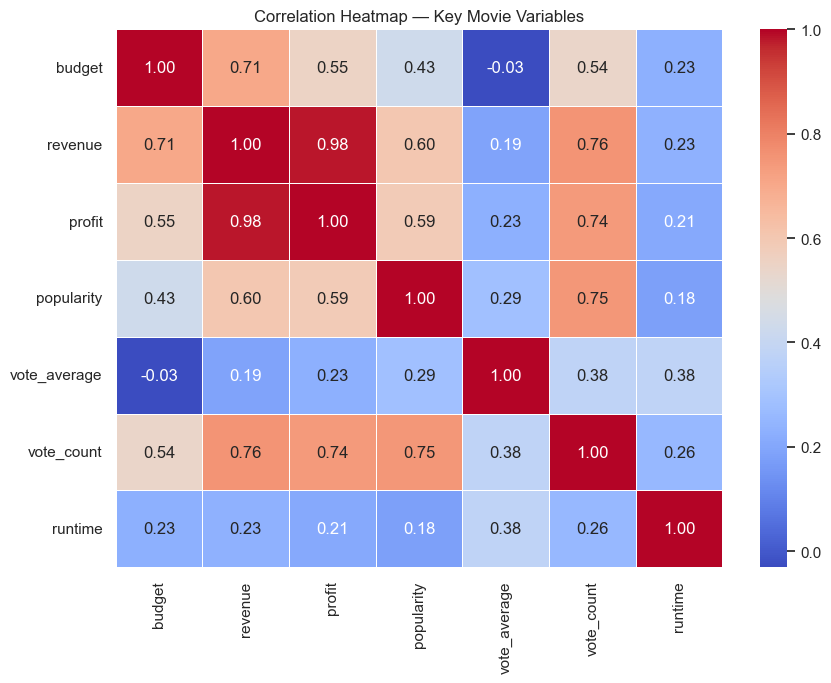

In [21]:
num_cols = ["budget", "revenue", "profit", "popularity", "vote_average", "vote_count", "runtime"]
corr = df[num_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap — Key Movie Variables")
plt.tight_layout()
plt.show()


**Insight:** `budget` (0.73) and `vote_count` (0.76) have the strongest correlations with revenue. `vote_average` (rating) is a weak predictor (0.19).

**Conclusion:** Budget, popularity, and vote count are the primary quantitative predictors of revenue. Rating alone is insufficient as a success indicator.

**Business Recommendation:** Track vote count after release as a downstream performance signal. Films accumulating votes rapidly are showing sustained audience engagement — a signal for extended theatrical runs.


### 7.4 Revenue by Genre

In [22]:
genre_rev = df.groupby("original_language")["revenue"].mean().sort_values(ascending=False)
print(genre_rev.head(10))


original_language
en    1.245451e+08
te    1.000000e+08
ja    8.126636e+07
zh    7.953696e+07
cn    6.296073e+07
xx    5.526056e+07
da    5.232305e+07
ko    5.102352e+07
de    4.159554e+07
es    3.362737e+07
Name: revenue, dtype: float64


**Insight:** English-language films dominate global average revenue, though select non-English films also show strong performance.

**Conclusion:** Language and cultural context significantly influence global revenue potential.

**Business Recommendation:** Global streaming platforms should use language-level revenue benchmarks to guide localisation and dubbing investment decisions.


### 7.5 Top 10 Highest-Grossing Movies

In [23]:
top10 = df.nlargest(10, "revenue")[["title", "budget", "revenue", "profit", "vote_average"]]
top10 = top10.reset_index(drop=True)
print(top10.to_string())


                        title     budget     revenue      profit  vote_average
0                      Avatar  237000000  2787965087  2550965087           7.2
1                     Titanic  200000000  1845034188  1645034188           7.5
2                The Avengers  220000000  1519557910  1299557910           7.4
3              Jurassic World  150000000  1513528810  1363528810           6.5
4                   Furious 7  190000000  1506249360  1316249360           7.3
5     Avengers: Age of Ultron  280000000  1405403694  1125403694           7.3
6                      Frozen  150000000  1274219009  1124219009           7.3
7                  Iron Man 3  200000000  1215439994  1015439994           6.8
8                     Minions   74000000  1156730962  1082730962           6.4
9  Captain America: Civil War  250000000  1153304495   903304495           7.1


**Insight:** The top 10 grossing films are all franchise or sequel entries. They all carry large budgets and earn profit multiples of 3–8x their cost.

**Conclusion:** Franchise films with established audiences are the most reliable path to blockbuster revenue.

**Business Recommendation:** Studios should treat intellectual property and franchise development as long-term capital investments. Even moderate-quality franchise films outperform high-quality standalone originals commercially.


## 8. Summary — Insights and Business Recommendations

| Analysis | Key Insight | Business Recommendation |
|----------|-------------|------------------------|
| Revenue Distribution | Right-skewed — blockbusters are rare outliers | Diversify slate; do not rely on a single hit |
| Budget Distribution | Most films cost under $50M | Benchmark against median, not mean |
| Ratings Distribution | Centered around 6.1; few extremes | Set minimum quality KPI of 6.5 |
| Budget vs Revenue | Strong correlation (0.73) | Budget is necessary but not sufficient |
| Rating vs Revenue | Weak correlation (0.19) | Separate event-film from quality-film strategy |
| Popularity vs Revenue | Moderate-strong (0.64) | Invest in pre-release social buzz tracking |
| Revenue by Year | Strong growth from 1980s to 2010s | Use last decade as financial benchmark |
| Top 10 Films | All are franchise entries | Acquire and develop IP as strategic assets |
| ROI Analysis | Micro-budget films lead ROI | Barbell portfolio: low-budget + mid-budget mix |

**Overall Recommendation:** The most commercially successful films combine an adequate production budget, strong franchise IP (drives popularity), and a minimum rating quality threshold above 6.5. Production companies should track budget, popularity, and vote count as their three core revenue prediction inputs.
